In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 2050


In [6]:
num_frames = 16
frame_step = 6
sample_indices = np.arange(
    0,
    num_frames * frame_step,
    frame_step
)

print(sample_indices)

[ 0  6 12 18 24 30 36 42 48 54 60 66 72 78 84 90]


In [ ]:
from pathlib import Path

base_dir = Path(r"C:\NNDL Lab Proj\KTH")
dataset_path = base_dir / "Dataset" if (base_dir / "Dataset").exists() else base_dir
video_path = dataset_path / "walking" / "person01_walking_d1_uncomp.avi"
cap = cv2.VideoCapture(str(video_path))

frames = []

for index in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(index))
    ret, frame = cap.read()

    if ret:
        frames.append(frame)

cap.release()

print("Number of frames:", len(frames))
print("Frame shape:", frames[0].shape)

Number of frames: 16
Frame shape: (120, 160, 3)


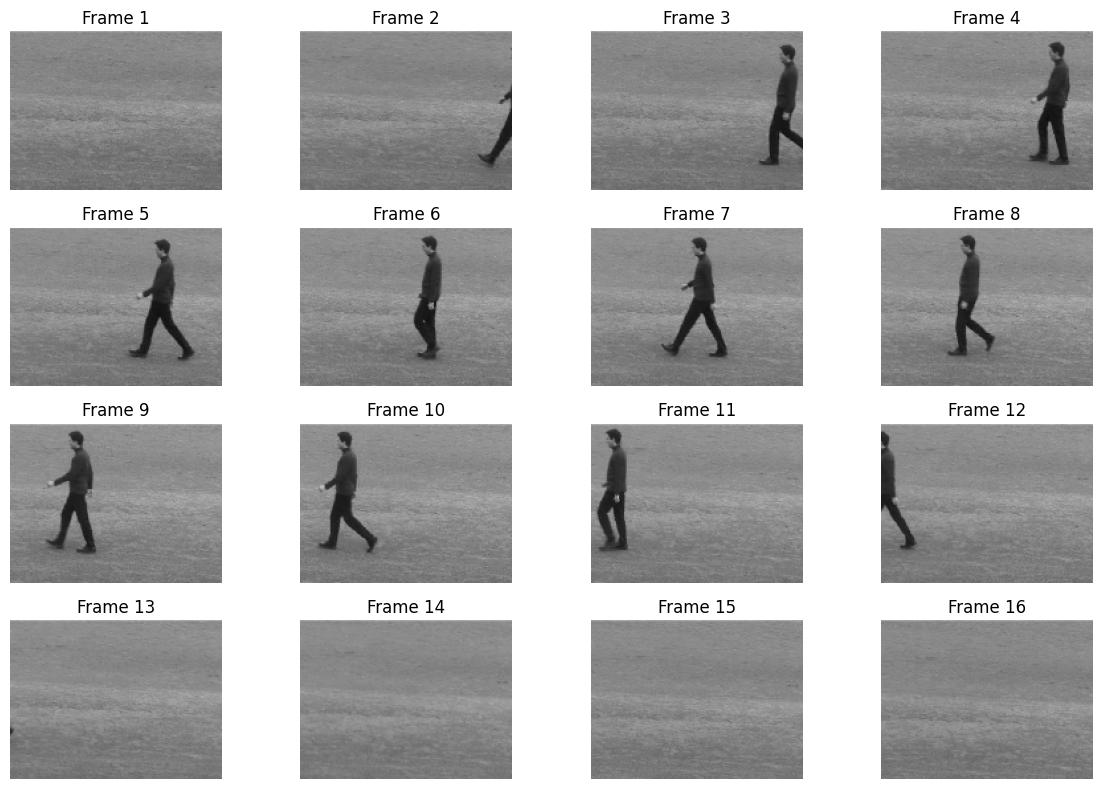

In [9]:
plt.figure(figsize=(12, 8))

for i, frame in enumerate(frames):
    plt.subplot(4, 4, i + 1)

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.imshow(frame_rgb)
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### preprocessing 


In [10]:
processed_frames = []

for frame in frames:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_resized = cv2.resize(frame_rgb, (112, 112))
    processed_frames.append(frame_resized)

print("Number of frames:", len(processed_frames))
print("Frame shape:", processed_frames[0].shape)

Number of frames: 16
Frame shape: (112, 112, 3)


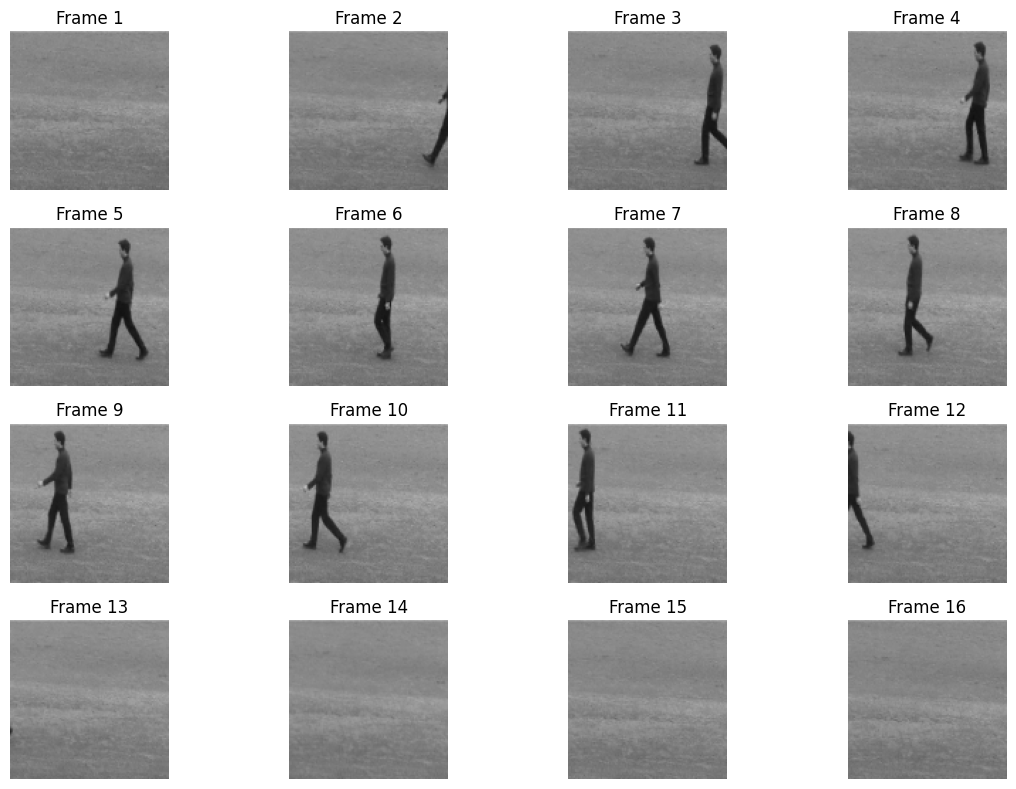

In [11]:
plt.figure(figsize=(12, 8))

for i, frame in enumerate(processed_frames):
    plt.subplot(4, 4, i + 1)
    plt.imshow(frame)
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Normalization

In [12]:
normalized_frames = []

for frame in processed_frames:
    frame = frame.astype(np.float32) / 255.0
    normalized_frames.append(frame)

print("Data type:", normalized_frames[0].dtype)
print("Minimum:", normalized_frames[0].min())
print("Maximum:", normalized_frames[0].max())

Data type: float32
Minimum: 0.3882353
Maximum: 0.69411767


In [14]:
frame_tensors = []

for frame in normalized_frames:
    tensor = torch.from_numpy(frame)
    tensor = tensor.permute(2, 0, 1)
    frame_tensors.append(tensor)

print("One frame:", frame_tensors[0].shape)

# Tensor creation for the entire video clip
video_tensor = torch.stack(frame_tensors)

print("Video tensor shape:", video_tensor.shape)


One frame: torch.Size([3, 112, 112])
Video tensor shape: torch.Size([16, 3, 112, 112])


### CNN Defining

In [15]:
import torch.nn as nn
class CNNFeatureExtractor(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
# added adaptive average pooling to reduce the spatial dimensions to 1x1
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return x

In [16]:
# Testing the CNN feature extractor with one frame
cnn = CNNFeatureExtractor()

one_frame = video_tensor[0].unsqueeze(0)

features = cnn(one_frame)

print("Input shape:", one_frame.shape)
print("Feature shape:", features.shape)

Input shape: torch.Size([1, 3, 112, 112])
Feature shape: torch.Size([1, 128])


In [17]:
# LRCN Implementation
# load the CNN feature extractor and process the entire video tensor
video_features = cnn(video_tensor)

print("Input shape:", video_tensor.shape)
print("Output shape:", video_features.shape)

Input shape: torch.Size([16, 3, 112, 112])
Output shape: torch.Size([16, 128])


### LSTM Defination

In [18]:
class LSTMClassifier(nn.Module):

    def __init__(self, input_size=128, hidden_size=128, num_classes=4):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)

        last_hidden = hidden[-1]

        prediction = self.fc(last_hidden)

        return prediction

In [19]:
sequence = video_features.unsqueeze(0)

print("Sequence shape:", sequence.shape)

Sequence shape: torch.Size([1, 16, 128])


In [21]:
lstm_model = LSTMClassifier()
prediction = lstm_model(sequence)

print("Prediction shape:", prediction.shape)
print("Prediction:", prediction)

Prediction shape: torch.Size([1, 4])
Prediction: tensor([[0.0742, 0.0811, 0.0075, 0.0198]], grad_fn=<AddmmBackward0>)
